# Case 2: 2D Upper-Body Interpersonal Dynamics (MOSAIC) — reproduction

Pairs converse across four background-noise levels (Office 60 → Café 70 → Food
Court 80 → Party 87.5 dB SPL), each partner recorded by a dedicated webcam. Case 2
quantifies **interpersonal coordination** via cross-recurrence between the two
partners' ROI velocity-magnitude signals.

## Configuration

Point this at the dataset and set the run toggle. `RUN_FULL = False` analyzes
a few sessions (good for iterating); `RUN_FULL = True` runs all 47 pairs to
reproduce the published figures.

In [26]:
import glob
import os

DATA_DIR = r"G:\mosaic movement files"
from pose_dynamics.case_studies.mosaic import default_conditions_csv, parse_file
CONDITIONS_CSV = default_conditions_csv()

RUN_FULL        = True        # False = a few sessions (fast); True = all 47 pairs
SUBSET_SESSIONS = [2, 3, 4]     # sessions analyzed when RUN_FULL is False

all_files = sorted(f for f in glob.glob(f"{DATA_DIR}/*.csv") if not os.path.basename(f).startswith("._"))
files = all_files if RUN_FULL else [f for f in all_files if parse_file(f)[0] in SUBSET_SESSIONS]
print(f"{len(all_files)} camera files present; analyzing {len(files)} "
      f"({'FULL' if RUN_FULL else 'subset'}).")

550 camera files present; analyzing 550 (FULL).


### Guard and results cache

Two safety rails.

**Guard.** Jupyter caches imported modules in `sys.modules`, so editing
`reproduce.py` or `config.py` has *no* effect on a kernel that already imported
them -- a plain "Run All" reuses the old code and produces byte-identical results
while looking like a fresh run. The guard asserts the loaded module matches what is
on disk, so that failure is loud instead of silent. If it fails, restart the kernel;
re-running will not help.

**Cache.** The six pipeline stages below each stream all camera files, so iterating
on the statistics used to mean recomputing everything. Results are memoized to
parquet, keyed on a fingerprint of the numeric config *and the source of every
function that shapes the ROI signals*. Any edit to preprocessing, alignment or
config changes the fingerprint and misses the cache, so a stale cache cannot be
silently reused -- the same failure the guard exists to catch. Set `REBUILD = True`
to force recomputation regardless.

In [ ]:
# --- guard: confirm the modules on disk are the ones actually loaded ---
import hashlib
import inspect
from pathlib import Path
# NOTE: aliased CFG, not C -- a bare 'C' shadows patsy's C() categorical
# function that the models vc_formula="0 + C(participant)" depends on.
from pose_dynamics.case_studies.mosaic import config as CFG
from pose_dynamics.case_studies.mosaic import reproduce as R
from pose_dynamics.case_studies.mosaic import stats as S


def _is_current(mod):
    """Was this module imported from the file that is on disk right now?

    Each module records a digest of its own source at import time. Comparing that against
    a fresh read detects a stale copy in sys.modules -- which a plain "Run All" would
    otherwise reuse silently. Note inspect.getsource cannot do this: it reads from disk
    too, so it always agrees with disk regardless of what is actually loaded.
    """
    fresh = hashlib.sha256(Path(mod.__file__).read_bytes()).hexdigest()[:12]
    return getattr(mod, "_SOURCE_SHA", None) == fresh


_src = inspect.getsource(R.preprocess_pose)
_checks = {
    # generic: catches any edit to either module, so this list never needs updating
    "reproduce.py loaded matches disk": _is_current(R),
    "stats.py loaded matches disk": _is_current(S),
    # specific: the settings the reproduction depends on
    "normalization is isotropic": CFG.VIDEO_WIDTH == CFG.VIDEO_HEIGHT,
    "video dims are 720x720": (CFG.VIDEO_WIDTH, CFG.VIDEO_HEIGHT) == (720, 720),
    "no per-frame nose centring in preprocess_pose": '"step": "center"' not in _src,
    "embedding committed at tau=10, m=4": (CFG.TAU, CFG.M) == (10, 4),
}
for _k, _v in _checks.items():
    print(("PASS" if _v else "FAIL"), "-", _k)
# Printed, not asserted: this one is a legitimate toggle (set False to measure
# what limb rescaling contributes), so it must not block experimentation.
print("info  - limb rescaling:", "ON" if CFG.APPLY_LIMB_RESCALE else "OFF")
assert all(_checks.values()), (
    "Loaded modules do not match disk (or config is unexpected). "
    "RESTART THE KERNEL -- re-running alone will silently reuse the cached module."
)

In [28]:
# --- results cache, keyed on the pipeline state that determines the ROI signals ---
import hashlib
import pandas as pd
from pathlib import Path

CACHE_DIR = Path("case2_cache"); CACHE_DIR.mkdir(exist_ok=True)
REBUILD = False        # True forces every stage below to recompute

def _pipeline_fingerprint() -> str:
    """Hash the numeric config, the analysed file set, and the *source* of every
    function that shapes the ROI signals.

    Hashing source rather than a version string is deliberate: it means an edit to
    preprocessing or alignment invalidates the cache automatically, with no
    discipline required from whoever makes the edit.
    """
    parts = [
        # Every upper-case config name and its value. Swept automatically rather than
        # hand-listed: a hand-listed tuple silently omitted APPLY_LIMB_RESCALE and
        # WINDOW_COMPLETENESS when they were added, so flipping either toggle left the
        # fingerprint unchanged and returned stale cached results -- the exact failure
        # this hash exists to prevent.
        repr(sorted((a, repr(getattr(CFG, a))) for a in dir(CFG) if a.isupper())),
        repr((RUN_FULL, len(files))),          # a subset run must not reuse a full-run cache
        *(inspect.getsource(f) for f in (
            R.preprocess_pose, R.windowed_align, R._window_roi_speeds,
            R.build_global_template, R.run_individual, R.process_dyad,
            R.auto_params, R.cross_params)),
    ]
    return hashlib.sha256("".join(parts).encode()).hexdigest()[:12]

FINGERPRINT = _pipeline_fingerprint()
print("pipeline fingerprint:", FINGERPRINT)

def cached(name, build):
    """Memoize a stage's tidy DataFrame on disk under the pipeline fingerprint."""
    path = CACHE_DIR / f"{name}.{FINGERPRINT}.parquet"
    if path.exists() and not REBUILD:
        print(f"[cache hit ] {name} <- {path.name}")
        out = pd.read_parquet(path)
    else:
        print(f"[cache miss] {name} -- computing (streams all {len(files)} files)")
        out = build()
        out.to_parquet(path, index=False)
        print(f"[cached    ] {name} -> {path.name}")
    # parquet does not reliably round-trip an ordered Categorical, and both the
    # models and the condition-ordered plots depend on it
    if "condition" in out.columns:
        out["condition"] = pd.Categorical(out["condition"], categories=CFG.CONDITION_ORDER,
                                          ordered=True)
    return out

pipeline fingerprint: 7ad3b8e9b633


## 1. Load a trial and resolve ROIs

`load_mosaic_file` reads the name-based OpenPose export and keeps only the ROI
keypoints — the manuscript's BODY_25 groups (arms, upper body) plus the face
region — resolving them by name.

In [29]:
from pose_dynamics.case_studies.mosaic import load_mosaic_file

seq, roi_map = load_mosaic_file(files[0])
print(seq.summary())
print("ROIs (keypoints each):", {roi: len(idx) for roi, idx in roi_map.items()})

{'source_file': 'G:\\mosaic movement files\\S002_T1_left.csv', 'n_frames': 18001, 'n_keypoints': 62, 'dims': 2, 'frame_rate': 60.0, 'has_confidence': True, 'missing_fraction': 0.0003, 'stages_applied': []}
ROIs (keypoints each): {'arms': 6, 'upper_body': 4, 'centre_face': 54}


## 2. ROI velocity-magnitude signals

`roi_velocity_signals` runs the individual preprocessing (mask 0.30 → interpolate →
10 Hz filter → normalize to [0,1] → downsample to 30 Hz), aggregates each ROI to
its centroid, and takes the velocity magnitude — the one-dimensional movement-
intensity signal per ROI.

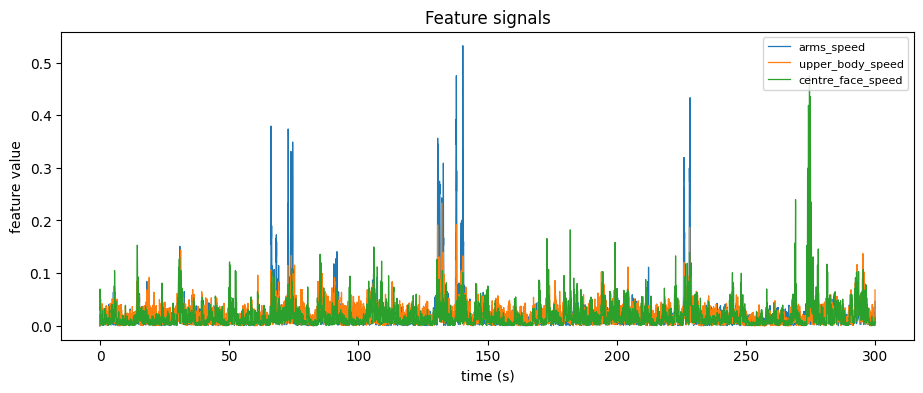

In [30]:
from pose_dynamics.case_studies.mosaic import roi_velocity_signals

feats = roi_velocity_signals(seq, roi_map)
feats.plot(names=[f"{r}_speed" for r in roi_map]);

## 3. Choosing the embedding parameters (human-in-the-loop)

At 30 Hz we estimate `(τ, m)` from AMI/FNN across the ROI signals, then commit.

The delay is proposed as a **range**, not a single value. The three AMI rules — first
prominent local minimum, plateau onset, and relative 1/e crossing — answer different
questions about the same curve, and on quasi-periodic pose signals they routinely
disagree by a factor of two or more; the per-signal spread adds more. Reporting their
span states what the evidence actually supports, and makes the width of that span
— how weakly the data constrain the delay — visible instead of hidden behind one
number.

The analysis still needs a single delay, so `commit()` takes a point value. The range
says which points are defensible: `commit()` warns if the committed delay falls
outside it.

Evidence from 40 of 1650 signals.

Delay (tau) — relative-shape / plateau heuristic (proposal, confirm from the plot):
  - first prominent local minimum (smoothed) at lag None.
  - plateau onset (diminishing returns) at lag 22.
  - relative 1/e crossing at lag 7.
  - per-signal median suggestion: 20.0.
  => supported range: tau in [10, 20] (estimators spanned [7, 22], clamped to grid [10, 20]).
     The rules above answer different questions, so they disagree; their span is what the evidence supports,
     and its width measures how weakly the data constrain the delay. Any tau in the interval is defensible.
     Single-point reading of the aggregate curve, for the record: 20.

Dimension (m) — FNN diminishing-returns knee at tau=20:
  - knee (elbow of the FNN curve): 4.
  - first dimension with FNN <= 10% (noise floor): 6.
  - per-signal median: 4.0.
  => proposed m = 4.

NOTE: these are proposals, not decisions. Inspect the curves and their spread, then commit a single (tau, m) with ev

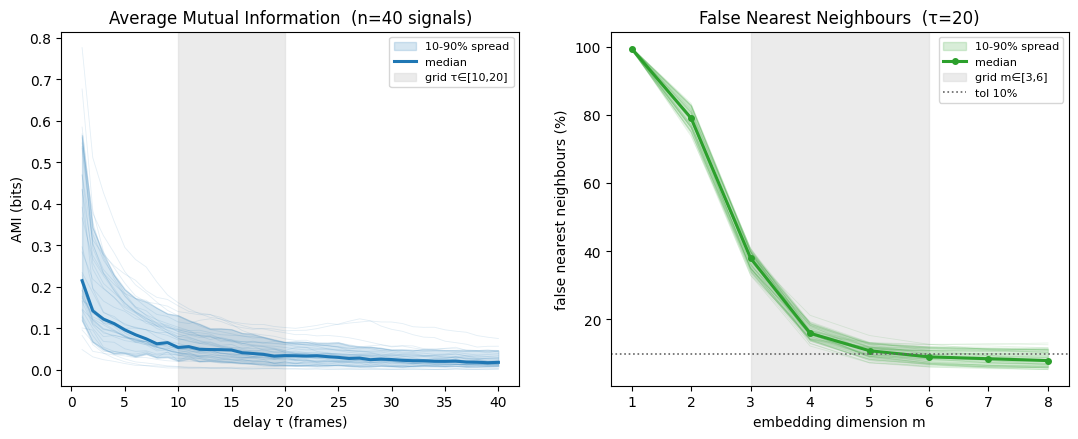

In [ ]:
from pose_dynamics.embedding import Signal, select_embedding, plot_embedding_evidence

signals = [Signal(label=s.label, values=s.values, group=s.group) for s in signals]

evidence = select_embedding(signals, tau_grid=(10, 20), m_grid=(3, 6),
                            ami_max_lag=40, fnn_max_dim=8, subset=40, seed=0)
plot_embedding_evidence(evidence)
print(evidence.justification)


In [84]:
params = evidence.commit(tau=10, m=4, notes="Case 2: committed from AMI/FNN")
params.to_dict()

{'tau': 10,
 'm': 4,
 'multivariate': False,
 'chosen_by': 'human_confirmed',
 'proposed_tau_range': (10, 20),
 'proposed_tau': 20,
 'proposed_m': 4,
 'n_signals': 40,
 'notes': 'Case 2: committed from AMI/FNN'}

## 4. Individual-level analysis

Per ROI, per 60 s window (50% overlap): RMS/mean/SD of velocity magnitude, grouped
by background-noise condition.

In [33]:
from pose_dynamics.case_studies.mosaic import run_individual

df = cached("individual_aligned",
            lambda: run_individual(files, CONDITIONS_CSV, progress=True))
print(f"{len(df)} window-rows")
df.groupby(["roi", "condition"], observed=True)[["rms", "mean_vel", "sd_vel"]].mean().round(4)

[cache hit ] individual_aligned <- individual_aligned.7ad3b8e9b633.parquet
16982 window-rows


rms  mean_vel  sd_vel
roi         condition                          
arms        Office     0.0583    0.0308  0.0489
            Cafe       0.0622    0.0334  0.0520
            Food       0.0718    0.0388  0.0599
            Party      0.0807    0.0443  0.0669
centre_face Office     0.0396    0.0266  0.0292
            Cafe       0.0409    0.0277  0.0299
            Food       0.0500    0.0340  0.0365
            Party      0.0599    0.0411  0.0434
upper_body  Office     0.0347    0.0253  0.0236
            Cafe       0.0362    0.0264  0.0247
            Food       0.0407    0.0297  0.0277
            Party      0.0453    0.0330  0.0308

## 5. Dyadic analysis

Interpersonal cross-recurrence between the two
partners' ROI signals, plus zero-lag velocity cross-correlation. It runs only when
both the `left` and `right` camera files are present for a session-trial.

In [34]:
from pose_dynamics.case_studies.mosaic import run_reproduction

try:
    dyad_df = cached("dyadic_aligned", lambda: run_reproduction(
        DATA_DIR, CONDITIONS_CSV,
        sessions=None if RUN_FULL else SUBSET_SESSIONS, progress=True))
    dyad_df.groupby(["roi", "condition"], observed=True)[
        ["cross_perc_recur", "cross_lmax", "xcorr_lag0"]].mean()
except FileNotFoundError as e:
    print("Dyadic reproduction unavailable:", e)

[cache hit ] dyadic_aligned <- dyadic_aligned.7ad3b8e9b633.parquet


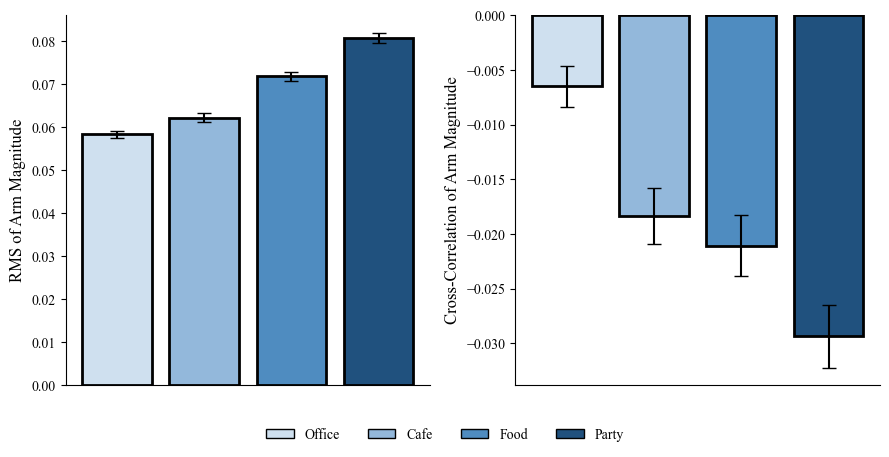

In [80]:
from pose_dynamics.case_studies.mosaic import plot_case2_figure

plot_case2_figure(df, dyad_df, arm_roi="arms");

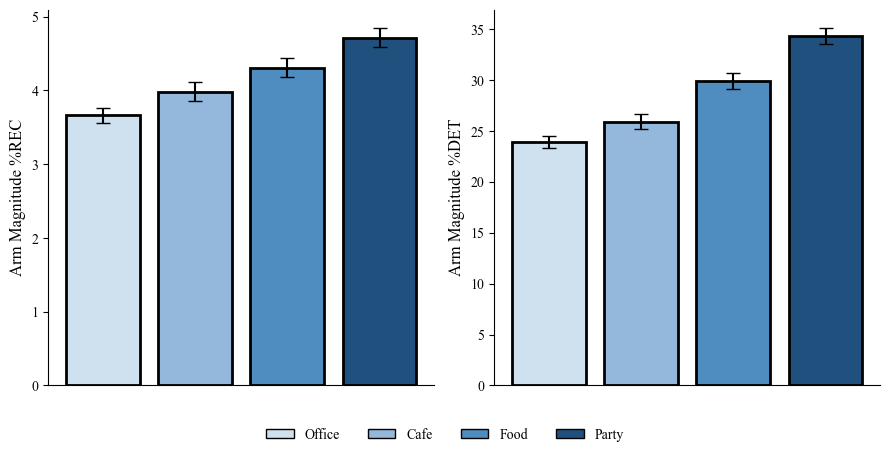

In [36]:
from pose_dynamics.case_studies.mosaic import plot_case2_crqa_figure

plot_case2_crqa_figure(dyad_df, roi="arms");

## 6. Inferential statistics

This runs linear mixed-effects models with a fixed effect of background-noise condition (Office as
reference), fit separately per ROI and per metric.

The model code lives in [`case_studies/mosaic/stats.py`](../src/pose_dynamics/case_studies/mosaic/stats.py); the cells below call it.

In [37]:
from pose_dynamics.case_studies.mosaic import (
    METRICS_DYAD, METRICS_IND, check_tukey_conservative, compare_alignment,
    fit_dyadic, fit_individual, to_trial_dyad, to_trial_individual, tukey_pairwise,
)

# --- primary fit: individual-level, trial means ---
df_trial = to_trial_individual(df)
coef_individual_df = fit_individual(df_trial)
print(f"individual: {len(df)} window rows -> {len(df_trial)} trial rows")
coef_individual_df

individual: 16982 window rows -> 1637 trial rows


,roi,metric,n_obs,df,converged,pair_var,individual_var,vs_Office,beta,SE,t,p
0,arms,rms,548,451,True,0.0002,0.0005,Cafe,0.0026,0.0020,1.2994,0.1945
1,arms,rms,548,451,True,0.0002,0.0005,Food,0.0139,0.0020,7.0193,0.0000
2,arms,rms,548,451,True,0.0002,0.0005,Party,0.0231,0.0020,11.4845,0.0000
3,arms,mean_vel,548,451,True,0.0000,0.0002,Cafe,0.0019,0.0011,1.8261,0.0685
4,arms,mean_vel,548,451,True,0.0000,0.0002,Food,0.0082,0.0011,7.7708,0.0000
5,arms,mean_vel,548,451,True,0.0000,0.0002,Party,0.0141,0.0011,13.1844,0.0000
6,arms,sd_vel,548,451,True,0.0001,0.0004,Cafe,0.0020,0.0018,1.1263,0.2607
7,arms,sd_vel,548,451,True,0.0001,0.0004,Food,0.0114,0.0017,6.5226,0.0000
8,arms,sd_vel,548,451,True,0.0001,0.0004,Party,0.0184,0.0018,10.4152,0.0000
9,upper_body,rms,546,449,True,0.0000,0.0001,Cafe,0.0014,0.0009,1.6293,0.1039


In [38]:
# --- primary fit: dyadic, trial means ---
dyad_trial = to_trial_dyad(dyad_df)
coef_dyad_df = fit_dyadic(dyad_trial)
print(f"dyadic: {len(dyad_df)} window rows -> {len(dyad_trial)} trial rows")
coef_dyad_df

dyadic: 7653 window rows -> 801 trial rows


,roi,metric,n_obs,df,converged,vs_Office,beta,SE,t,p
0,arms,xcorr_lag0,270,220,True,Cafe,-0.0121,0.0049,-2.4798,0.0139
1,arms,xcorr_lag0,270,220,True,Food,-0.0151,0.0048,-3.1228,0.0020
2,arms,xcorr_lag0,270,220,True,Party,-0.0205,0.0049,-4.1849,0.0000
3,arms,cross_perc_recur,270,220,True,Cafe,0.2636,0.2831,0.9313,0.3527
4,arms,cross_perc_recur,270,220,True,Food,0.7840,0.2810,2.7898,0.0057
...,...,...,...,...,...,...,...,...,...,...
67,centre_face,cross_entropy,263,213,True,Food,0.2679,0.0504,5.3142,0.0000
68,centre_face,cross_entropy,263,213,True,Party,0.3212,0.0518,6.2043,0.0000
69,centre_face,cross_trapping_time,263,213,True,Cafe,0.2814,0.1005,2.8001,0.0056
70,centre_face,cross_trapping_time,263,213,True,Food,0.4519,0.0968,4.6684,0.0000


In [39]:
tukey_individual = tukey_pairwise(df_trial, METRICS_IND, "individual")
tukey_dyad = tukey_pairwise(dyad_trial, METRICS_DYAD, "dyad")

n = check_tukey_conservative(tukey_individual, coef_individual_df)
print(f"sanity: Tukey p >= unadjusted p for all {n} reference contrasts")
tukey_individual

sanity: Tukey p >= unadjusted p for all 27 reference contrasts


,roi,metric,contrast,diff,SE,t,df,p_tukey
0,arms,rms,Cafe - Office,0.0026,0.0020,1.2994,451,0.5638
1,arms,rms,Food - Office,0.0139,0.0020,7.0193,451,0.0000
2,arms,rms,Party - Office,0.0231,0.0020,11.4845,451,0.0000
3,arms,rms,Food - Cafe,0.0113,0.0024,4.6448,451,0.0000
4,arms,rms,Party - Cafe,0.0205,0.0025,8.3301,451,0.0000
5,arms,rms,Party - Food,0.0091,0.0025,3.7268,451,0.0012
6,arms,mean_vel,Cafe - Office,0.0019,0.0011,1.8261,451,0.2624
7,arms,mean_vel,Food - Office,0.0082,0.0011,7.7708,451,0.0000
8,arms,mean_vel,Party - Office,0.0141,0.0011,13.1844,451,0.0000
9,arms,mean_vel,Food - Cafe,0.0063,0.0013,4.8247,451,0.0000


In [40]:
tukey_dyad

,roi,metric,contrast,diff,SE,t,df,p_tukey
0,arms,xcorr_lag0,Cafe - Office,-0.0121,0.0049,-2.4798,220,0.0659
1,arms,xcorr_lag0,Food - Office,-0.0151,0.0048,-3.1228,220,0.0109
2,arms,xcorr_lag0,Party - Office,-0.0205,0.0049,-4.1849,220,0.0002
3,arms,xcorr_lag0,Food - Cafe,-0.0030,0.0059,-0.5078,220,0.9572
4,arms,xcorr_lag0,Party - Cafe,-0.0085,0.0060,-1.4139,220,0.4920
...,...,...,...,...,...,...,...,...
139,centre_face,cross_trapping_time,Food - Office,0.4519,0.0968,4.6684,213,0.0000
140,centre_face,cross_trapping_time,Party - Office,0.5725,0.0994,5.7582,213,0.0000
141,centre_face,cross_trapping_time,Food - Cafe,0.1706,0.1211,1.4083,213,0.4956
142,centre_face,cross_trapping_time,Party - Cafe,0.2912,0.1228,2.3708,213,0.0859


## 7. Procrustes alignment comparison

Reviewers asked how much of Case 2's individual- and dyadic-level results depend
on the windowed Procrustes alignment step (`windowed_align`, in `reproduce.py`).
`run_individual`/`run_reproduction` take `align: bool = True`; passing
`align=False` skips the per-window rotation/scale fit and uses only the window's
mean-nose-centred coordinates. The cells below rerun both pipelines with
`align=False`, refit the same mixed-effects models, and compare the resulting
coefficients side by side with the aligned versions above.

In [41]:
from pose_dynamics.case_studies.mosaic import run_individual

df_noalign = cached("individual_noalign",
                    lambda: run_individual(files, CONDITIONS_CSV, align=False, progress=True))
print(f"{len(df_noalign)} window-rows")
df_noalign.groupby(["roi", "condition"], observed=True)[["rms", "mean_vel", "sd_vel"]].mean().round(4)

[cache hit ] individual_noalign <- individual_noalign.7ad3b8e9b633.parquet
16982 window-rows


rms  mean_vel  sd_vel
roi         condition                          
arms        Office     0.0587    0.0313  0.0490
            Cafe       0.0645    0.0349  0.0538
            Food       0.0722    0.0395  0.0599
            Party      0.0815    0.0453  0.0672
centre_face Office     0.0402    0.0269  0.0297
            Cafe       0.0415    0.0280  0.0303
            Food       0.0511    0.0347  0.0373
            Party      0.0617    0.0423  0.0447
upper_body  Office     0.0351    0.0256  0.0238
            Cafe       0.0366    0.0267  0.0249
            Food       0.0416    0.0304  0.0283
            Party      0.0467    0.0341  0.0318

In [42]:
from pose_dynamics.case_studies.mosaic import run_reproduction

try:
    dyad_df_noalign = cached("dyadic_noalign", lambda: run_reproduction(
        DATA_DIR, CONDITIONS_CSV,
        sessions=None if RUN_FULL else SUBSET_SESSIONS, align=False, progress=True))
    dyad_df_noalign.groupby(["roi", "condition"], observed=True)[
        ["cross_perc_recur", "cross_lmax", "xcorr_lag0"]].mean()
except FileNotFoundError as e:
    print("Dyadic reproduction unavailable:", e)

[cache hit ] dyadic_noalign <- dyadic_noalign.7ad3b8e9b633.parquet


In [43]:
coef_individual_noalign_df = fit_individual(to_trial_individual(df_noalign))
coef_individual_noalign_df

,roi,metric,n_obs,df,converged,pair_var,individual_var,vs_Office,beta,SE,t,p
0,arms,rms,548,451,True,0.0001,0.0005,Cafe,0.0043,0.0022,2.0022,0.0459
1,arms,rms,548,451,True,0.0001,0.0005,Food,0.0137,0.0021,6.3921,0.0000
2,arms,rms,548,451,True,0.0001,0.0005,Party,0.0236,0.0022,10.8413,0.0000
3,arms,mean_vel,548,451,True,0.0000,0.0001,Cafe,0.0029,0.0012,2.5008,0.0127
4,arms,mean_vel,548,451,True,0.0000,0.0001,Food,0.0082,0.0011,7.2118,0.0000
5,arms,mean_vel,548,451,True,0.0000,0.0001,Party,0.0146,0.0012,12.6357,0.0000
6,arms,sd_vel,548,451,True,0.0001,0.0004,Cafe,0.0034,0.0019,1.8112,0.0708
7,arms,sd_vel,548,451,True,0.0001,0.0004,Food,0.0111,0.0019,5.8868,0.0000
8,arms,sd_vel,548,451,True,0.0001,0.0004,Party,0.0186,0.0019,9.7619,0.0000
9,upper_body,rms,546,449,True,0.0000,0.0001,Cafe,0.0015,0.0009,1.6231,0.1053


In [44]:
coef_dyad_noalign_df = fit_dyadic(to_trial_dyad(dyad_df_noalign))
coef_dyad_noalign_df

,roi,metric,n_obs,df,converged,vs_Office,beta,SE,t,p
0,arms,xcorr_lag0,270,220,True,Cafe,-0.0121,0.0050,-2.4406,0.0155
1,arms,xcorr_lag0,270,220,True,Food,-0.0149,0.0049,-3.0333,0.0027
2,arms,xcorr_lag0,270,220,True,Party,-0.0188,0.0050,-3.7716,0.0002
3,arms,cross_perc_recur,270,220,True,Cafe,0.3134,0.2754,1.1379,0.2564
4,arms,cross_perc_recur,270,220,True,Food,0.6284,0.2734,2.2986,0.0225
...,...,...,...,...,...,...,...,...,...,...
67,centre_face,cross_entropy,263,213,True,Food,0.2679,0.0504,5.3142,0.0000
68,centre_face,cross_entropy,263,213,True,Party,0.3212,0.0518,6.2043,0.0000
69,centre_face,cross_trapping_time,263,213,True,Cafe,0.2814,0.1005,2.8001,0.0056
70,centre_face,cross_trapping_time,263,213,True,Food,0.4519,0.0968,4.6684,0.0000


In [45]:
individual_comparison = compare_alignment(coef_individual_df, coef_individual_noalign_df)
dyad_comparison = compare_alignment(coef_dyad_df, coef_dyad_noalign_df)

print(f"Individual-level: {individual_comparison['sig_changed'].sum()}/{len(individual_comparison)} "
      "terms flip significance without alignment")
print(f"Dyadic: {dyad_comparison['sig_changed'].sum()}/{len(dyad_comparison)} "
      "terms flip significance without alignment")
individual_comparison

Individual-level: 2/27 terms flip significance without alignment
Dyadic: 0/72 terms flip significance without alignment


,roi,metric,n_obs_aligned,df_aligned,converged_aligned,pair_var_aligned,individual_var_aligned,vs_Office,beta_aligned,SE_aligned,...,df_noalign,converged_noalign,pair_var_noalign,individual_var_noalign,beta_noalign,SE_noalign,t_noalign,p_noalign,beta_diff,sig_changed
0,arms,rms,548,451,True,0.0002,0.0005,Cafe,0.0026,0.0020,...,451,True,0.0001,0.0005,0.0043,0.0022,2.0022,0.0459,-0.0017,True
1,arms,rms,548,451,True,0.0002,0.0005,Food,0.0139,0.0020,...,451,True,0.0001,0.0005,0.0137,0.0021,6.3921,0.0000,0.0002,False
2,arms,rms,548,451,True,0.0002,0.0005,Party,0.0231,0.0020,...,451,True,0.0001,0.0005,0.0236,0.0022,10.8413,0.0000,-0.0005,False
3,arms,mean_vel,548,451,True,0.0000,0.0002,Cafe,0.0019,0.0011,...,451,True,0.0000,0.0001,0.0029,0.0012,2.5008,0.0127,-0.0010,True
4,arms,mean_vel,548,451,True,0.0000,0.0002,Food,0.0082,0.0011,...,451,True,0.0000,0.0001,0.0082,0.0011,7.2118,0.0000,0.0000,False
5,arms,mean_vel,548,451,True,0.0000,0.0002,Party,0.0141,0.0011,...,451,True,0.0000,0.0001,0.0146,0.0012,12.6357,0.0000,-0.0005,False
6,arms,sd_vel,548,451,True,0.0001,0.0004,Cafe,0.0020,0.0018,...,451,True,0.0001,0.0004,0.0034,0.0019,1.8112,0.0708,-0.0014,False
7,arms,sd_vel,548,451,True,0.0001,0.0004,Food,0.0114,0.0017,...,451,True,0.0001,0.0004,0.0111,0.0019,5.8868,0.0000,0.0003,False
8,arms,sd_vel,548,451,True,0.0001,0.0004,Party,0.0184,0.0018,...,451,True,0.0001,0.0004,0.0186,0.0019,9.7619,0.0000,-0.0002,False
9,upper_body,rms,546,449,True,0.0000,0.0001,Cafe,0.0014,0.0009,...,449,True,0.0000,0.0001,0.0015,0.0009,1.6231,0.1053,-0.0001,False


In [46]:
dyad_comparison

,roi,metric,n_obs_aligned,df_aligned,converged_aligned,vs_Office,beta_aligned,SE_aligned,t_aligned,p_aligned,n_obs_noalign,df_noalign,converged_noalign,beta_noalign,SE_noalign,t_noalign,p_noalign,beta_diff,sig_changed
0,arms,xcorr_lag0,270,220,True,Cafe,-0.0121,0.0049,-2.4798,0.0139,270,220,True,-0.0121,0.0050,-2.4406,0.0155,0.0000,False
1,arms,xcorr_lag0,270,220,True,Food,-0.0151,0.0048,-3.1228,0.0020,270,220,True,-0.0149,0.0049,-3.0333,0.0027,-0.0002,False
2,arms,xcorr_lag0,270,220,True,Party,-0.0205,0.0049,-4.1849,0.0000,270,220,True,-0.0188,0.0050,-3.7716,0.0002,-0.0017,False
3,arms,cross_perc_recur,270,220,True,Cafe,0.2636,0.2831,0.9313,0.3527,270,220,True,0.3134,0.2754,1.1379,0.2564,-0.0498,False
4,arms,cross_perc_recur,270,220,True,Food,0.7840,0.2810,2.7898,0.0057,270,220,True,0.6284,0.2734,2.2986,0.0225,0.1556,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,centre_face,cross_entropy,263,213,True,Food,0.2679,0.0504,5.3142,0.0000,263,213,True,0.2679,0.0504,5.3142,0.0000,0.0000,False
68,centre_face,cross_entropy,263,213,True,Party,0.3212,0.0518,6.2043,0.0000,263,213,True,0.3212,0.0518,6.2043,0.0000,0.0000,False
69,centre_face,cross_trapping_time,263,213,True,Cafe,0.2814,0.1005,2.8001,0.0056,263,213,True,0.2814,0.1005,2.8001,0.0056,0.0000,False
70,centre_face,cross_trapping_time,263,213,True,Food,0.4519,0.0968,4.6684,0.0000,263,213,True,0.4519,0.0968,4.6684,0.0000,0.0000,False


### Figures

The same comparison as the coefficient tables above, drawn. One bar per strategy within
each condition:

1. **Linear metrics.** Reported in absolute units, so alignment matters: the Procrustes
   scale step corrects between-participant differences in pixel scale that arise when
   partners sit at different distances from their cameras.
2. **CRQA, centre-face and upper body.** The velocity magnitude time series used here are z-scored prior to analysis, so Procrustes does not change the results here.
3. **CRQA, arms.** Here the bars do differ, as limb-length
   normalisation rescales upper-limb segments to fixed template lengths, reintroducing
   absolute scale and so restoring sensitivity to the alignment's scale factor. Disabling
   that step makes these bars identical too.

In [47]:
strategy_individual = {"Aligned": df, "Unaligned": df_noalign}
strategy_dyad = {"Aligned": dyad_df, "Unaligned": dyad_df_noalign}

# the exact-invariance claim above, checked rather than asserted
_k = ["session", "trial", "roi", "window"]
_m = dyad_df.merge(dyad_df_noalign, on=_k, suffixes=("_a", "_u"))
for _roi, _g in _m.groupby("roi", observed=True):
    _d = max(abs(_g[f"{c}_a"] - _g[f"{c}_u"]).max()
             for c in ("cross_perc_recur", "cross_perc_determ", "cross_lmax"))
    print(f"{_roi:12} max |aligned - unaligned| across all CRQA metrics: {_d:.3e}")

arms         max |aligned - unaligned| across all CRQA metrics: 9.500e+01
centre_face  max |aligned - unaligned| across all CRQA metrics: 0.000e+00
upper_body   max |aligned - unaligned| across all CRQA metrics: 0.000e+00


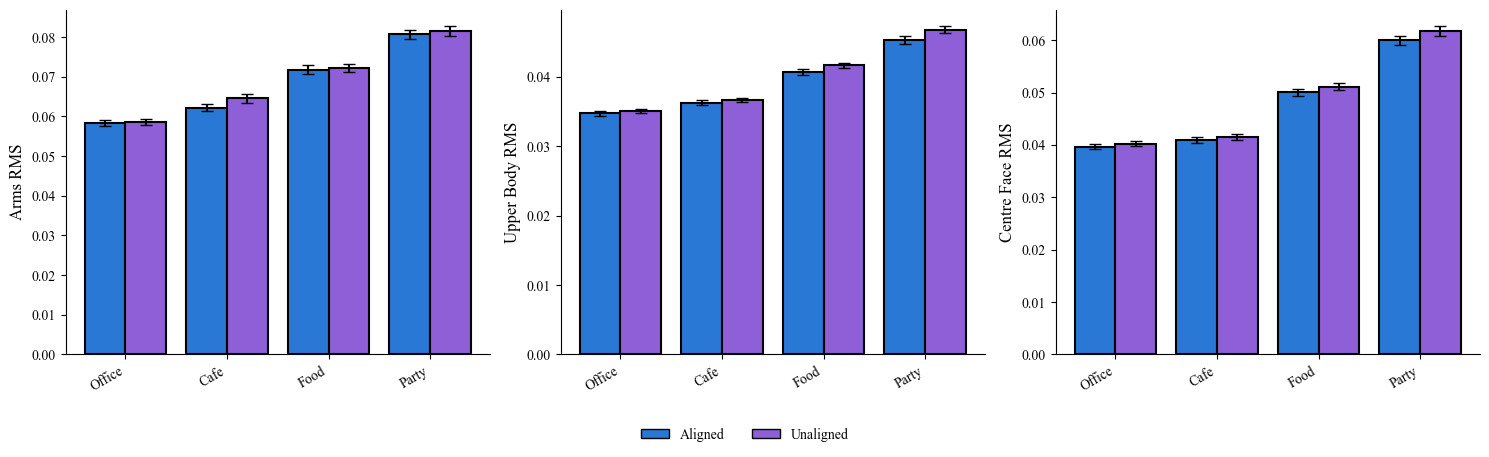

In [48]:
from pose_dynamics.case_studies.mosaic import plot_alignment_comparison_linear

# 1. Linear metrics -- absolute units, so alignment changes them
plot_alignment_comparison_linear(strategy_individual);

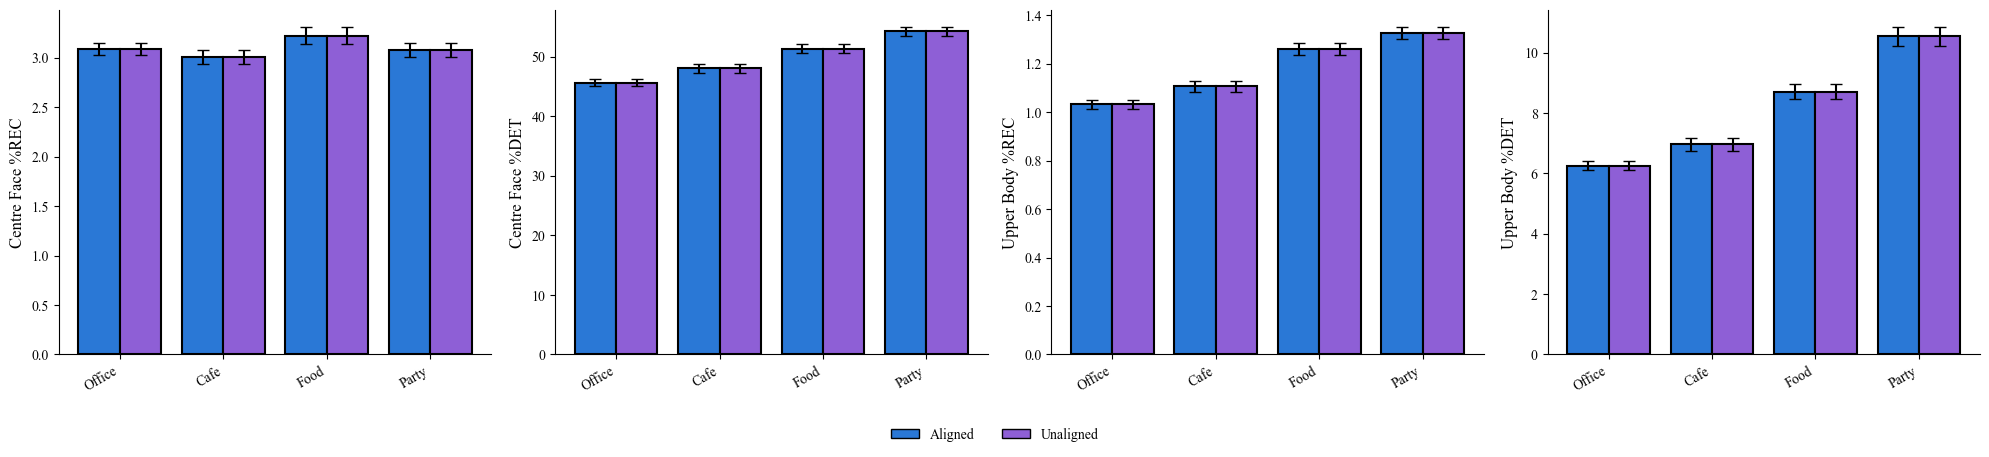

In [49]:
from pose_dynamics.case_studies.mosaic import plot_alignment_comparison_crqa_invariant

# 2. CRQA for the ROIs alignment cannot affect -- bars identical by construction
plot_alignment_comparison_crqa_invariant(strategy_dyad);

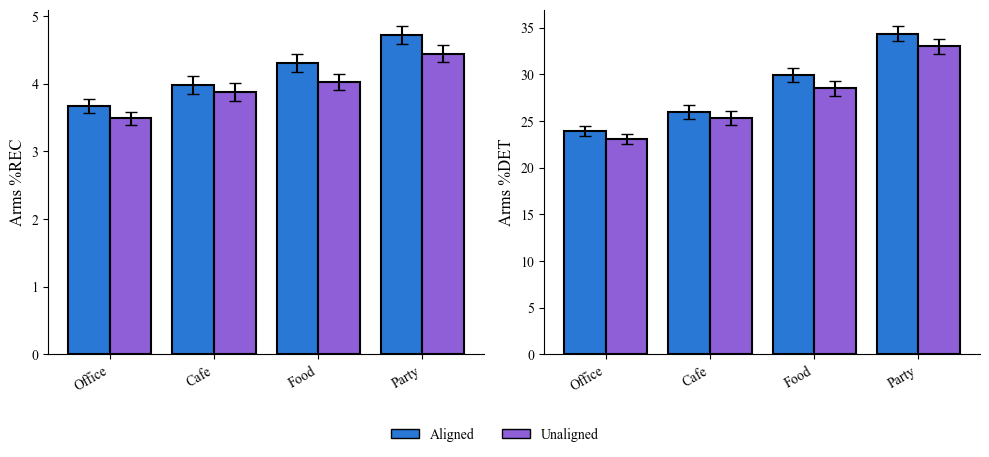

In [50]:
from pose_dynamics.case_studies.mosaic import plot_alignment_comparison_crqa_arms

# 3. CRQA for the arms -- differs, via limb-length normalisation rather than geometry
plot_alignment_comparison_crqa_arms(strategy_dyad);